In [17]:
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
train_df = pd.read_parquet("../data/app_train_final.parquet")

prod_df = pd.read_csv("../monitoring/predictions.csv")

print(train_df.shape)
print(prod_df.shape)

(307507, 305)
(100, 5)


## Amount Income Total

### Analyse visuelle (KDE)

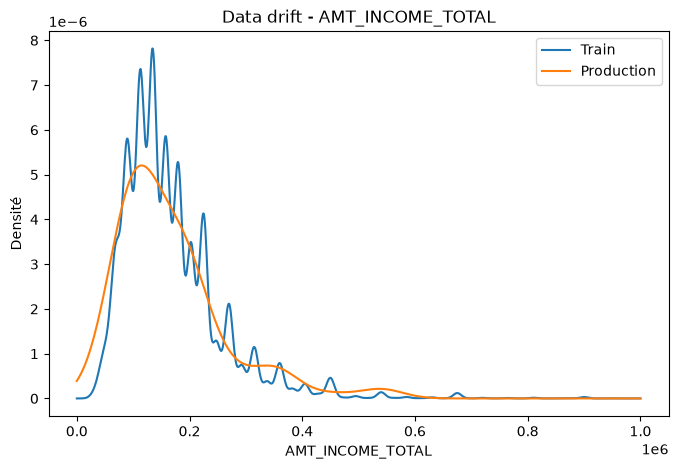

In [19]:
from scipy.stats import gaussian_kde
import numpy as np

train_income = train_df["AMT_INCOME_TOTAL"]
prod_income = prod_df["AMT_INCOME_TOTAL"]

# On limite les valeurs extrêmes
train_income = train_income[train_income < 1_000_000]
prod_income = prod_income[prod_income < 1_000_000]

x = np.linspace(0, 1_000_000, 1000)

train_kde = gaussian_kde(train_income)
prod_kde = gaussian_kde(prod_income)

plt.figure(figsize=(8,5))

plt.plot(x, train_kde(x), label="Train")
plt.plot(x, prod_kde(x), label="Production")

plt.xlabel("AMT_INCOME_TOTAL")
plt.ylabel("Densité")
plt.title("Data drift - AMT_INCOME_TOTAL")
plt.legend()

plt.show()



- Les deux jeux de données ont des tailles très différentes : 307 507 observations pour le jeu d'entraînement contre seulement 100 observations en production. Un histogramme classique n'est donc pas idéal pour comparer directement les deux distributions.

- Une courbe KDE (Kernel Density Estimation) fournit une estimation lissée de la densité de probabilité. Elle permet de comparer la répartition des revenus indépendamment du nombre d'observations, ce qui rend les deux jeux comparables.

- Les courbes obtenues pour la variable `AMT_INCOME_TOTAL` sont globalement similaires. Les deux distributions présentent un pic autour de 100 000 – 150 000 et une asymétrie à droite caractéristique de quelques revenus élevés.

- Aucun signe évident de data drift n'est observé sur cette variable.



### Analyse descriptive (Boxplot)

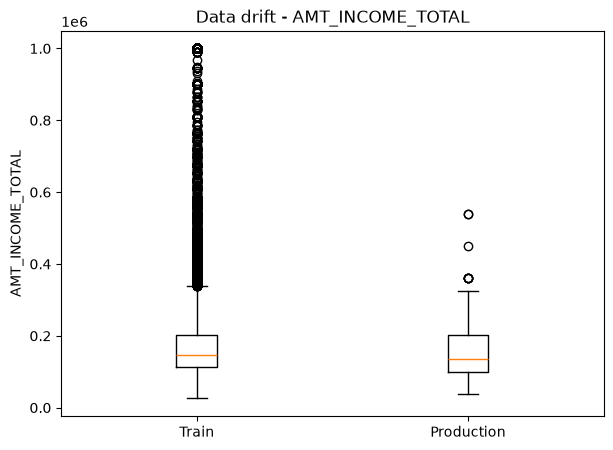

In [20]:
plt.figure(figsize=(7,5))

plt.boxplot(
    [
        train_df["AMT_INCOME_TOTAL"].clip(upper=1_000_000),
        prod_df["AMT_INCOME_TOTAL"]
    ],
    tick_labels=["Train", "Production"]
)

plt.ylabel("AMT_INCOME_TOTAL")
plt.title("Data drift - AMT_INCOME_TOTAL")

plt.show()

- Le boxplot confirme les observations issues des courbes KDE.

- Les médianes des distributions Train et Production sont très proches, ce qui indique que le revenu typique des clients n'a pas significativement évolué entre les données d'entraînement et les données de production.

- Les intervalles interquartiles (IQR) présentent également des amplitudes similaires, suggérant une dispersion comparable des revenus dans les deux populations.

- Enfin, les deux jeux de données présentent des valeurs extrêmes et une asymétrie à droite, caractéristique de la présence de quelques clients ayant des revenus particulièrement élevés.

- Ces observations confirment l'absence de signe évident de data drift pour la variable `AMT_INCOME_TOTAL`.

### Test de Kolmogorov-Smirnov

Le test de Kolmogorov-Smirnov (KS) permet de comparer quantitativement les distributions des données d'entraînement et des données de production.

L'hypothèse nulle H0 suppose que les deux échantillons proviennent de la même distribution.
²
Un seuil de significativité de 5 % est utilisé.

- Si la p-value est supérieure à 0.05, aucune différence statistiquement significative n'est détectée.
- Si la p-value est inférieure ou égale à 0.05, les distributions sont considérées comme différentes, ce qui peut constituer un signe de data drift.

In [21]:
from scipy.stats import ks_2samp
ks_stat, p_value = ks_2samp(
    train_df["AMT_INCOME_TOTAL"],
    prod_df["AMT_INCOME_TOTAL"]
)

print(f"KS statistic = {ks_stat:.4f}")
print(f"p-value = {p_value:.4f}")

KS statistic = 0.0744
p-value = 0.6110


- KS = écart maximal entre les fonctions de répartition des deux échantillons
    - 0 -> distribution identique
    - 1 -> distribution complètement différente
=> KS = 0.07 les distributions sont très proches

- P value = probabilité d'observers un écart au moins aussi grand que celui observé 
    - petite -> écart très peux probable 
    - grande => écart compatible avec des fluctuations aléatoires normales
=> P value = 0.6 donc l'écart observé est compatible avec des fluctuations aléatoires normales

## Amount Credit

### KDE 

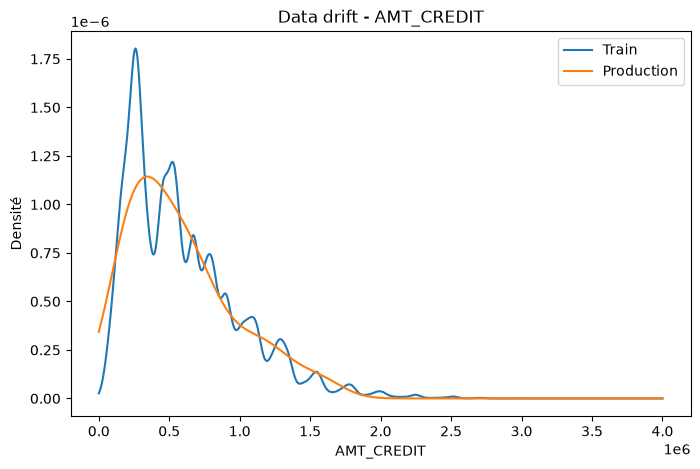

In [22]:
credit_train = train_df["AMT_CREDIT"]
credit_prod = prod_df["AMT_CREDIT"]

# Suppression des valeurs extrêmes
credit_train = credit_train[credit_train < 4_000_000]
credit_prod = credit_prod[credit_prod < 4_000_000]

x = np.linspace(0, 4_000_000, 1000)

train_kde = gaussian_kde(credit_train)
prod_kde = gaussian_kde(credit_prod)

plt.figure(figsize=(8,5))

plt.plot(x, train_kde(x), label="Train")
plt.plot(x, prod_kde(x), label="Production")

plt.xlabel("AMT_CREDIT")
plt.ylabel("Densité")
plt.title("Data drift - AMT_CREDIT")
plt.legend()

plt.show()

### Boxplot

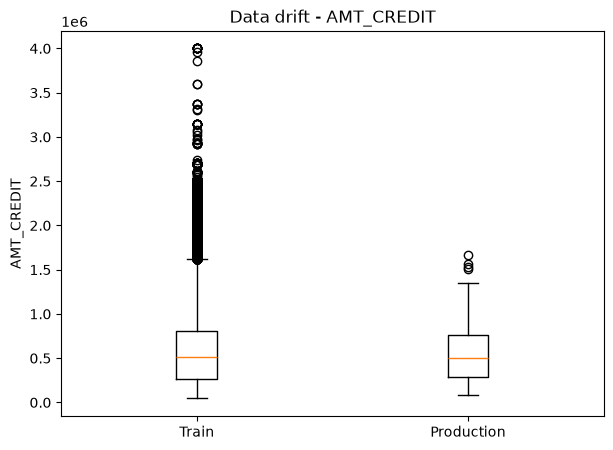

In [12]:
plt.figure(figsize=(7,5))

plt.boxplot(
    [
        train_df["AMT_CREDIT"].clip(upper=4_000_000),
        prod_df["AMT_CREDIT"]
    ],
    tick_labels=["Train", "Production"]
)

plt.ylabel("AMT_CREDIT")
plt.title("Data drift - AMT_CREDIT")

plt.show()

### KS

In [13]:
ks_stat, p_value = ks_2samp(
    train_df["AMT_CREDIT"],
    prod_df["AMT_CREDIT"]
)

print(f"KS statistic = {ks_stat:.4f}")
print(f"p-value = {p_value:.4f}")

alpha = 0.05

if p_value > alpha:
    print("No significant drift detected.")
else:
    print("Significant drift detected.")

KS statistic = 0.0438
p-value = 0.9865
No significant drift detected.


## Days Birth

### KDE

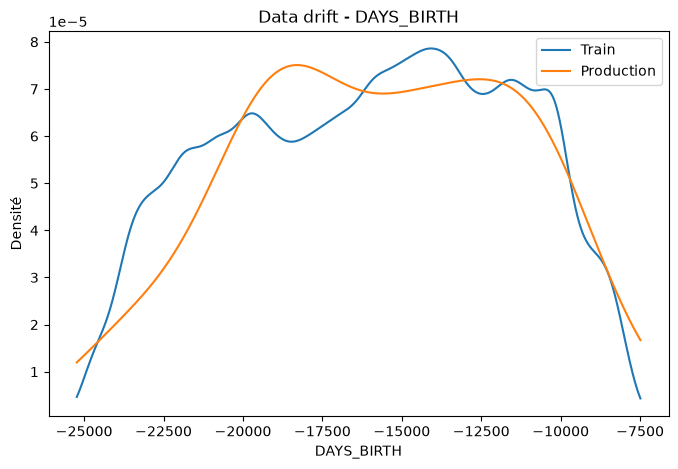

In [14]:
birth_train = train_df["DAYS_BIRTH"]
birth_prod = prod_df["DAYS_BIRTH"]

x = np.linspace(
    train_df["DAYS_BIRTH"].min(),
    train_df["DAYS_BIRTH"].max(),
    1000
)

train_kde = gaussian_kde(birth_train)
prod_kde = gaussian_kde(birth_prod)

plt.figure(figsize=(8,5))

plt.plot(x, train_kde(x), label="Train")
plt.plot(x, prod_kde(x), label="Production")

plt.xlabel("DAYS_BIRTH")
plt.ylabel("Densité")
plt.title("Data drift - DAYS_BIRTH")
plt.legend()

plt.show()

### Boxplot

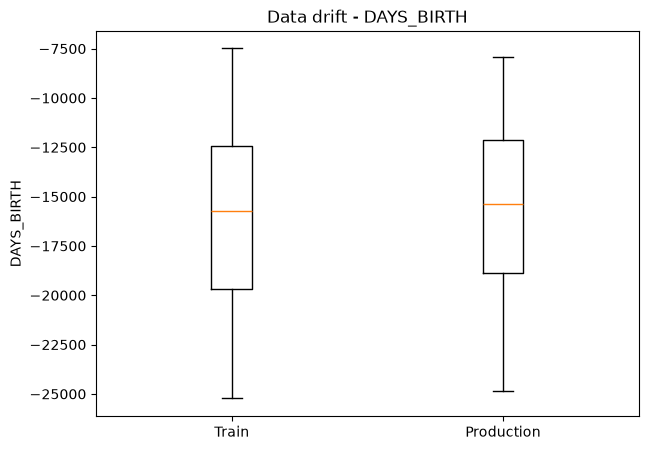

In [15]:
plt.figure(figsize=(7,5))

plt.boxplot(
    [
        train_df["DAYS_BIRTH"],
        prod_df["DAYS_BIRTH"]
    ],
    tick_labels=["Train", "Production"]
)

plt.ylabel("DAYS_BIRTH")
plt.title("Data drift - DAYS_BIRTH")

plt.show()

### KS

In [16]:
ks_stat, p_value = ks_2samp(
    train_df["DAYS_BIRTH"],
    prod_df["DAYS_BIRTH"]
)

print(f"KS statistic = {ks_stat:.4f}")
print(f"p-value = {p_value:.4f}")

alpha = 0.05

if p_value > alpha:
    print("No significant drift detected.")
else:
    print("Significant drift detected.")

KS statistic = 0.0859
p-value = 0.4282
No significant drift detected.
